# 서울시 기온에 따른 따릉이·지하철 이용 분석 — PPT용 EDA

**목적:** 기존 EDA의 분석 내용은 유지하되, 발표자료에 바로 사용할 수 있도록 그래프의 가독성·색상·라벨·저장 방식을 정리한 버전입니다.

- 분석 대상: 2025년 3·6·9·12월
- 기본 분석 범위: 평일·비공휴일
- 핵심 비교: 기온 ↔ 따릉이 / 기온 ↔ 지하철
- 그래프는 실행 시 `eda_figures` 폴더에 PNG로 저장됩니다.
- **Spearman은 scipy 의존성을 제거하기 위해 순위(rank)로 변환한 뒤 Pearson 상관을 계산합니다.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# -------------------------
# 기본 설정
# -------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1400)

# Windows 한글 폰트
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

sns.set_theme(style='whitegrid', font=font_name)

# 발표용 색상
BICYCLE_COLOR = '#2E7D32'
SUBWAY_COLOR = '#1565C0'
TEMP_COLOR = '#E65100'
ACCENT_COLOR = '#6A1B9A'
GRID_COLOR = '#D9D9D9'

FIG_DIR = Path('eda_figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, fontsize=16, fontweight='bold', pad=14)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=11)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8, alpha=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def save_fig(fig, name):
    path = FIG_DIR / f'{name}.png'
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight', facecolor='white')
    print(f'저장: {path}')
    return path

def add_bar_labels(ax, fmt='{:.0f}'):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=4, fontsize=10)

def spearman_corr(frame, x_cols=None):
    # Spearman = 각 변수의 순위(rank) 간 Pearson 상관
    if x_cols is None:
        x_cols = frame.columns
    return frame[list(x_cols)].rank(method='average').corr(method='pearson')

## 1. 데이터 로드 및 분석 범위

In [2]:
data_path = r'data\processed\analysis_dataset.csv'
df = pd.read_csv(data_path, encoding='utf-8-sig')
df['날짜'] = pd.to_datetime(df['날짜'])

analysis_df = df[(~df['주말여부']) & (~df['공휴일여부'])].copy()
analysis_df = analysis_df.reset_index(drop=True)

month_name = {3:'3월', 6:'6월', 9:'9월', 12:'12월'}
analysis_df['월'] = analysis_df['날짜'].dt.month
analysis_df['월명'] = analysis_df['월'].map(month_name)

hour_order = ['06-07','07-08','08-09','09-10','10-11','11-12','12-13','13-14',
              '14-15','15-16','16-17','17-18','18-19','19-20','20-21','21-22','22-23','23-24']

print(f'전체 데이터: {len(df):,}행')
print(f'평일·비공휴일 분석 데이터: {len(analysis_df):,}행')
print(f'기간: {analysis_df["날짜"].min().date()} ~ {analysis_df["날짜"].max().date()}')

전체 데이터: 2,196행
평일·비공휴일 분석 데이터: 1,494행
기간: 2025-03-04 ~ 2025-12-31


## 2. 기초통계

In [3]:
stats = analysis_df[['기온(°C)','따릉이대여건수','지하철승차인원']].describe().T
stats

,count,mean,std,min,25%,50%,75%,max
기온(°C),1494.0,14.674096,10.960095,-11.8,4.40,17.9,24.00,33.6
따릉이대여건수,1494.0,5933.419009,3815.027594,102.0,3391.25,4964.5,7695.75,19943.0
지하철승차인원,1494.0,281945.211513,132248.287337,51115.0,199355.50,237287.0,329742.00,632005.0


## 3. 분포 확인 — EDA 참고용

저장: eda_figures\01_기온_분포.png


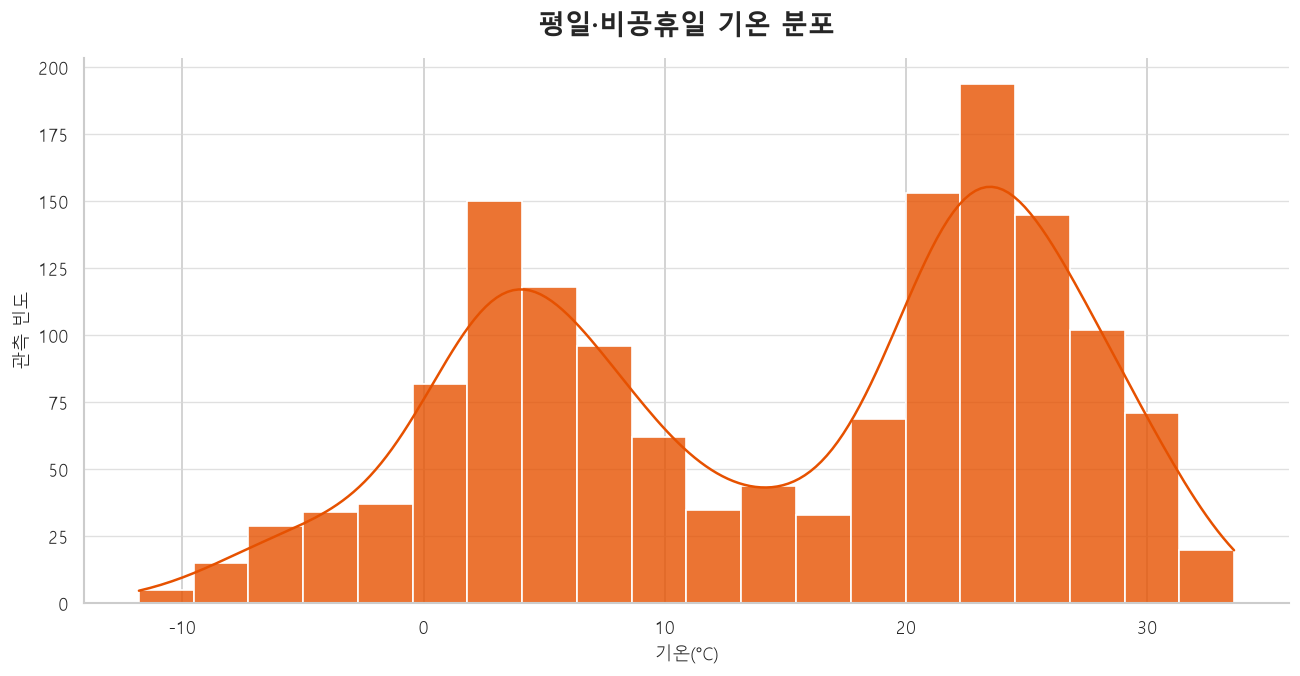

In [4]:
fig, ax = plt.subplots(figsize=(11,5.8))
sns.histplot(data=analysis_df, x='기온(°C)', bins=20, kde=True, color=TEMP_COLOR, alpha=0.8, ax=ax)
style_ax(ax, '평일·비공휴일 기온 분포', '기온(°C)', '관측 빈도')
save_fig(fig, '01_기온_분포')
plt.show()

저장: eda_figures\02_따릉이_분포.png


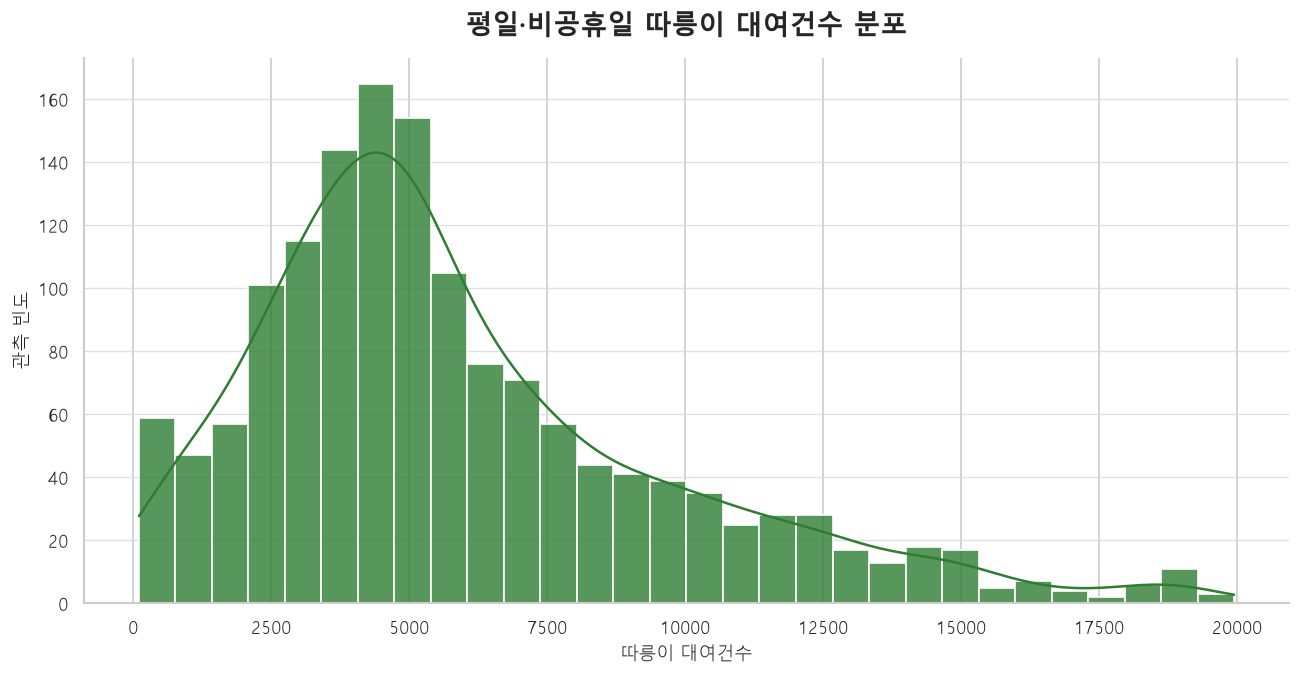

In [5]:
fig, ax = plt.subplots(figsize=(11,5.8))
sns.histplot(data=analysis_df, x='따릉이대여건수', bins=30, kde=True, color=BICYCLE_COLOR, alpha=0.8, ax=ax)
style_ax(ax, '평일·비공휴일 따릉이 대여건수 분포', '따릉이 대여건수', '관측 빈도')
save_fig(fig, '02_따릉이_분포')
plt.show()

저장: eda_figures\03_지하철_분포.png


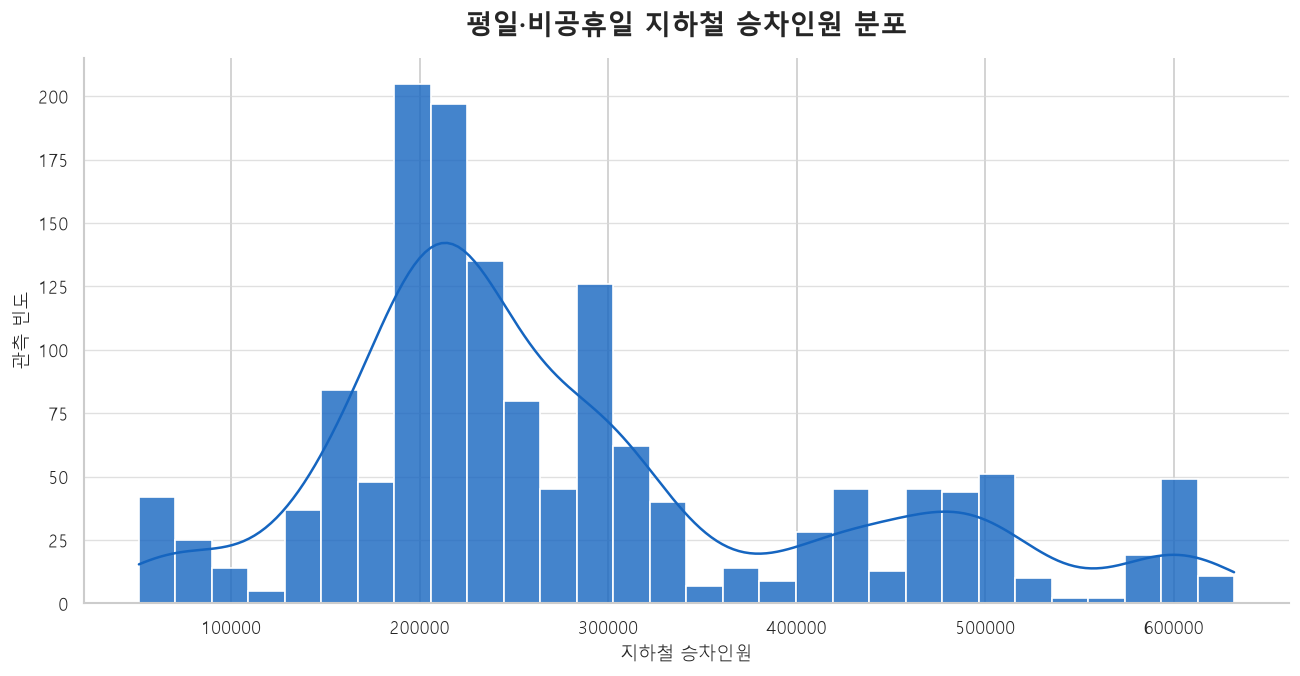

In [6]:
fig, ax = plt.subplots(figsize=(11,5.8))
sns.histplot(data=analysis_df, x='지하철승차인원', bins=30, kde=True, color=SUBWAY_COLOR, alpha=0.8, ax=ax)
style_ax(ax, '평일·비공휴일 지하철 승차인원 분포', '지하철 승차인원', '관측 빈도')
save_fig(fig, '03_지하철_분포')
plt.show()

## 4. 월별 이용 현황

In [7]:
monthly = (analysis_df.groupby(['월','월명']).agg(평균기온=('기온(°C)','mean'), 평균따릉이=('따릉이대여건수','mean'), 평균지하철=('지하철승차인원','mean'), 일수=('날짜','nunique')).reset_index().sort_values('월'))
monthly

,월,월명,평균기온,평균따릉이,평균지하철,일수
0,3,3월,9.040833,5440.152778,283382.986111,20
1,6,6월,24.757895,7354.494152,278205.005848,19
2,9,9월,24.220202,7305.353535,280545.040404,22
3,12,12월,1.540404,3782.616162,285268.492424,22


저장: eda_figures\04_월별_평균기온.png


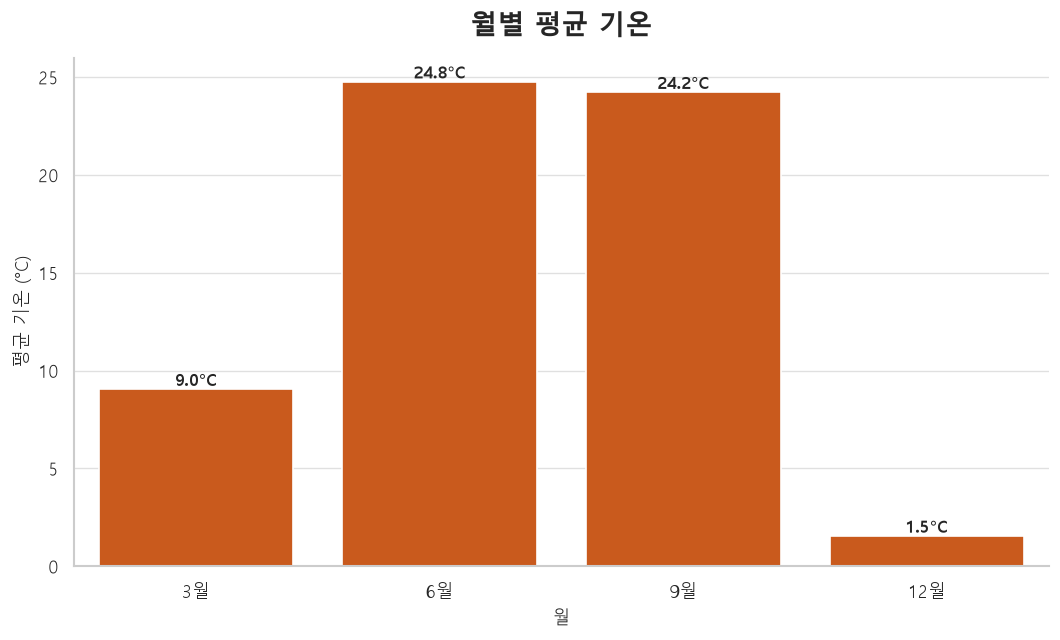

In [8]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(data=monthly, x='월명', y='평균기온', color=TEMP_COLOR, ax=ax)
style_ax(ax, '월별 평균 기온', '월', '평균 기온 (°C)')
for bar, v in zip(ax.patches, monthly['평균기온']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}°C', ha='center', va='bottom', fontsize=10, fontweight='bold')
save_fig(fig, '04_월별_평균기온')
plt.show()

저장: eda_figures\05_월별_평균따릉이.png


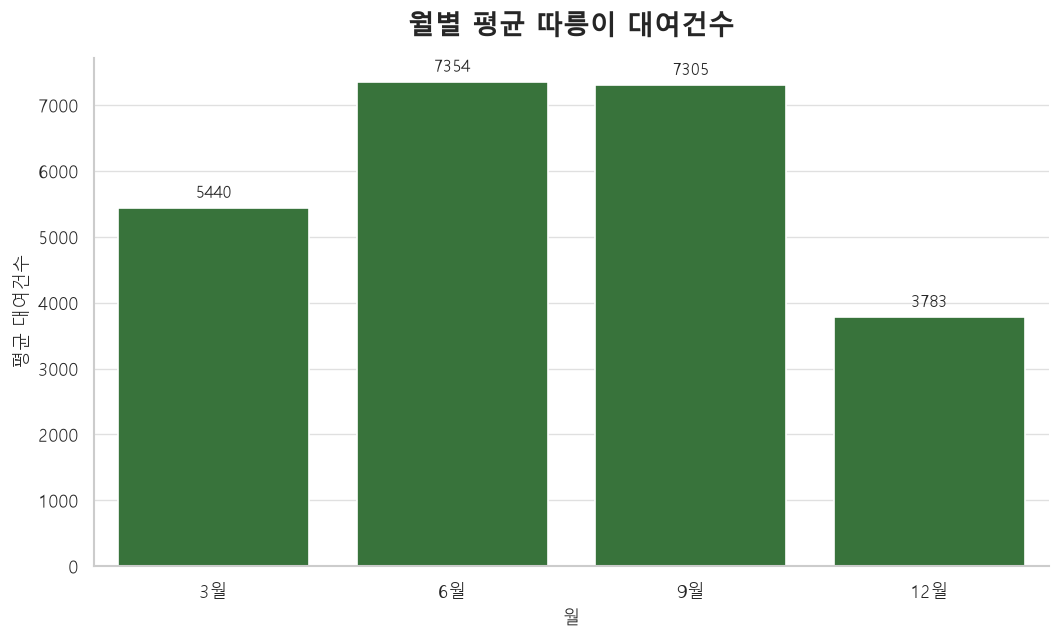

In [9]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(data=monthly, x='월명', y='평균따릉이', color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '월별 평균 따릉이 대여건수', '월', '평균 대여건수')
add_bar_labels(ax, fmt='{:.0f}')
save_fig(fig, '05_월별_평균따릉이')
plt.show()

저장: eda_figures\06_월별_평균지하철.png


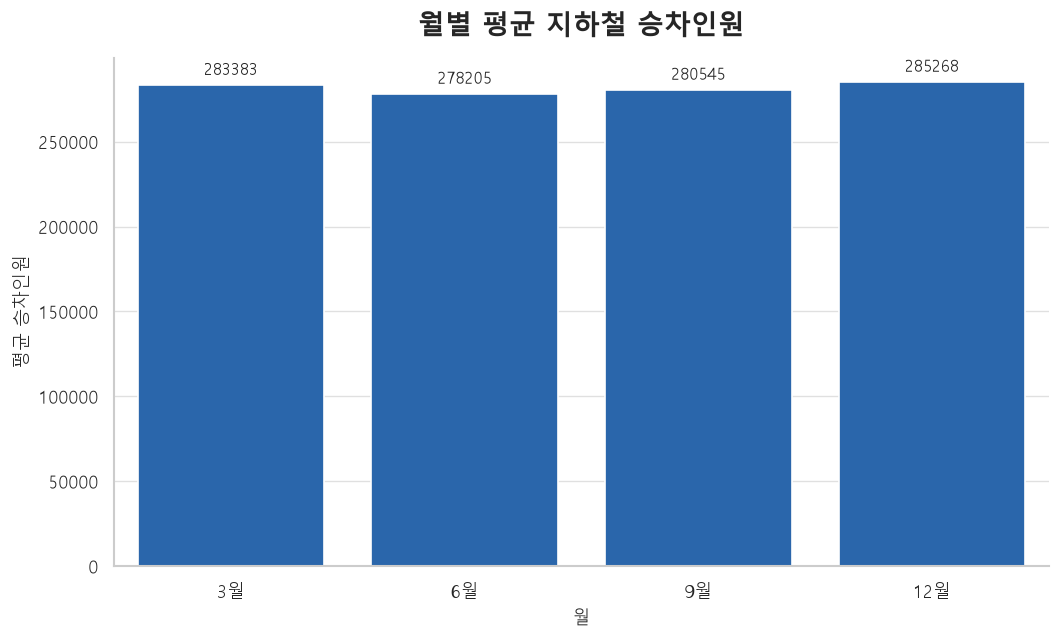

In [10]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(data=monthly, x='월명', y='평균지하철', color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '월별 평균 지하철 승차인원', '월', '평균 승차인원')
add_bar_labels(ax, fmt='{:.0f}')
save_fig(fig, '06_월별_평균지하철')
plt.show()

## 5. 시간대별 이용 패턴

In [11]:
hourly = (analysis_df.groupby('시간대').agg(평균따릉이=('따릉이대여건수','mean'), 평균지하철=('지하철승차인원','mean')).reindex(hour_order).reset_index())

저장: eda_figures\07_시간대별_평균따릉이.png


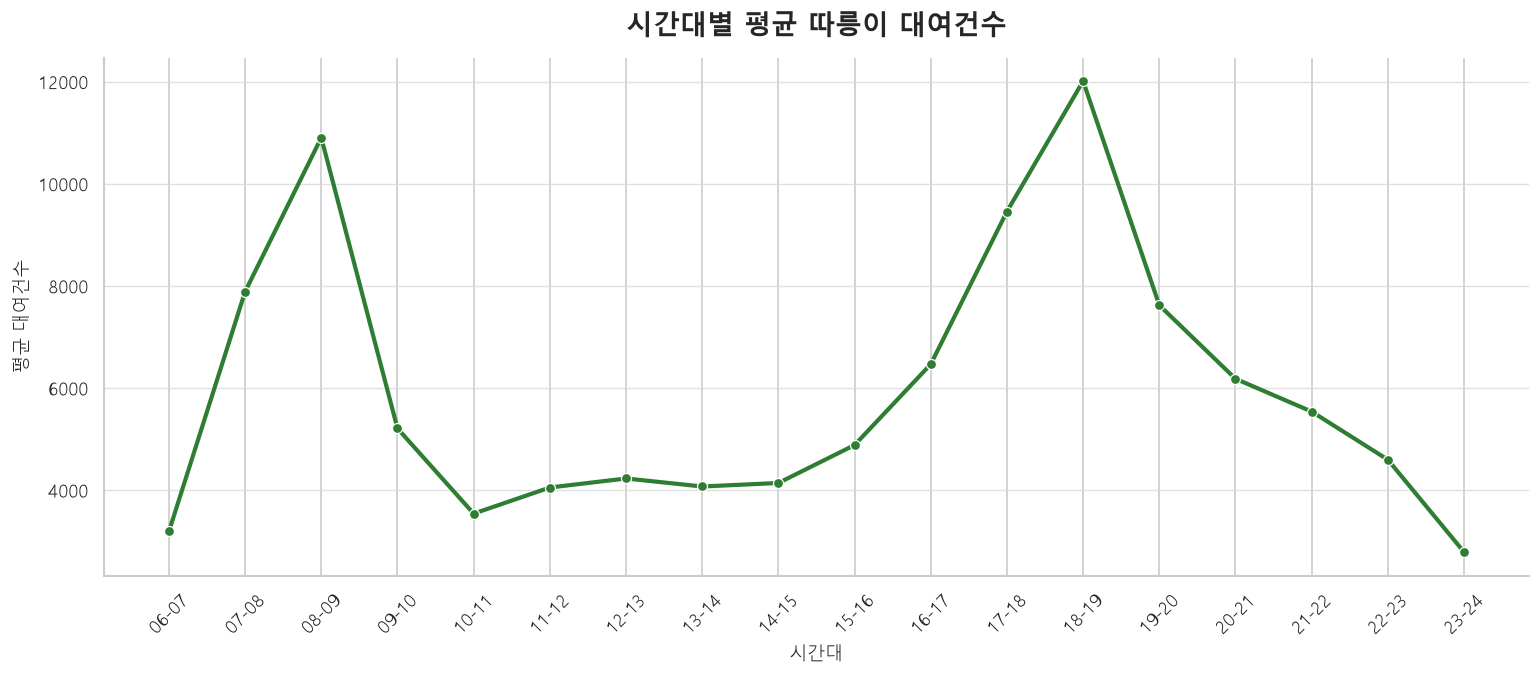

In [12]:
fig, ax = plt.subplots(figsize=(13,5.8))
sns.lineplot(data=hourly, x='시간대', y='평균따릉이', color=BICYCLE_COLOR, marker='o', linewidth=2.5, ax=ax)
style_ax(ax, '시간대별 평균 따릉이 대여건수', '시간대', '평균 대여건수')
ax.tick_params(axis='x', rotation=45)
save_fig(fig, '07_시간대별_평균따릉이')
plt.show()

저장: eda_figures\08_시간대별_평균지하철.png


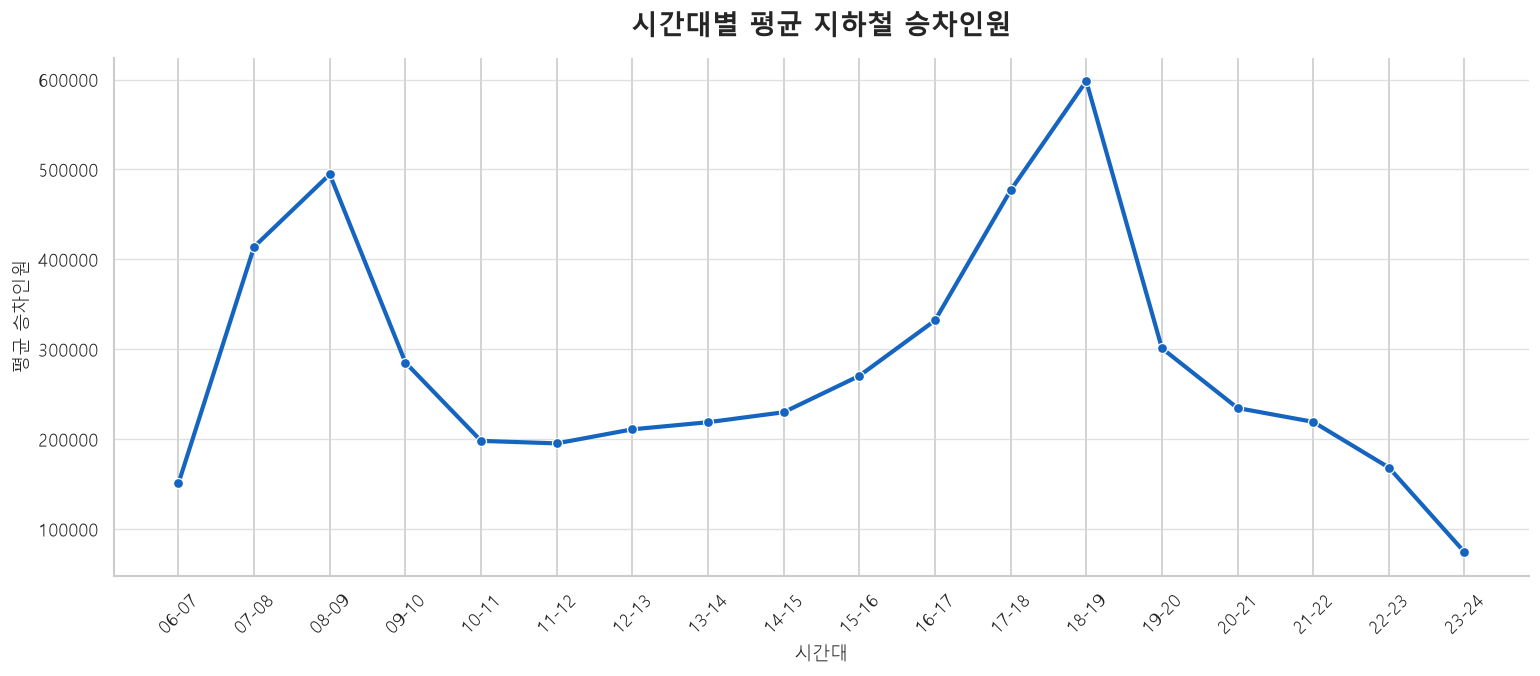

In [13]:
fig, ax = plt.subplots(figsize=(13,5.8))
sns.lineplot(data=hourly, x='시간대', y='평균지하철', color=SUBWAY_COLOR, marker='o', linewidth=2.5, ax=ax)
style_ax(ax, '시간대별 평균 지하철 승차인원', '시간대', '평균 승차인원')
ax.tick_params(axis='x', rotation=45)
save_fig(fig, '08_시간대별_평균지하철')
plt.show()

저장: eda_figures\09_시간대별_이용지수_비교.png


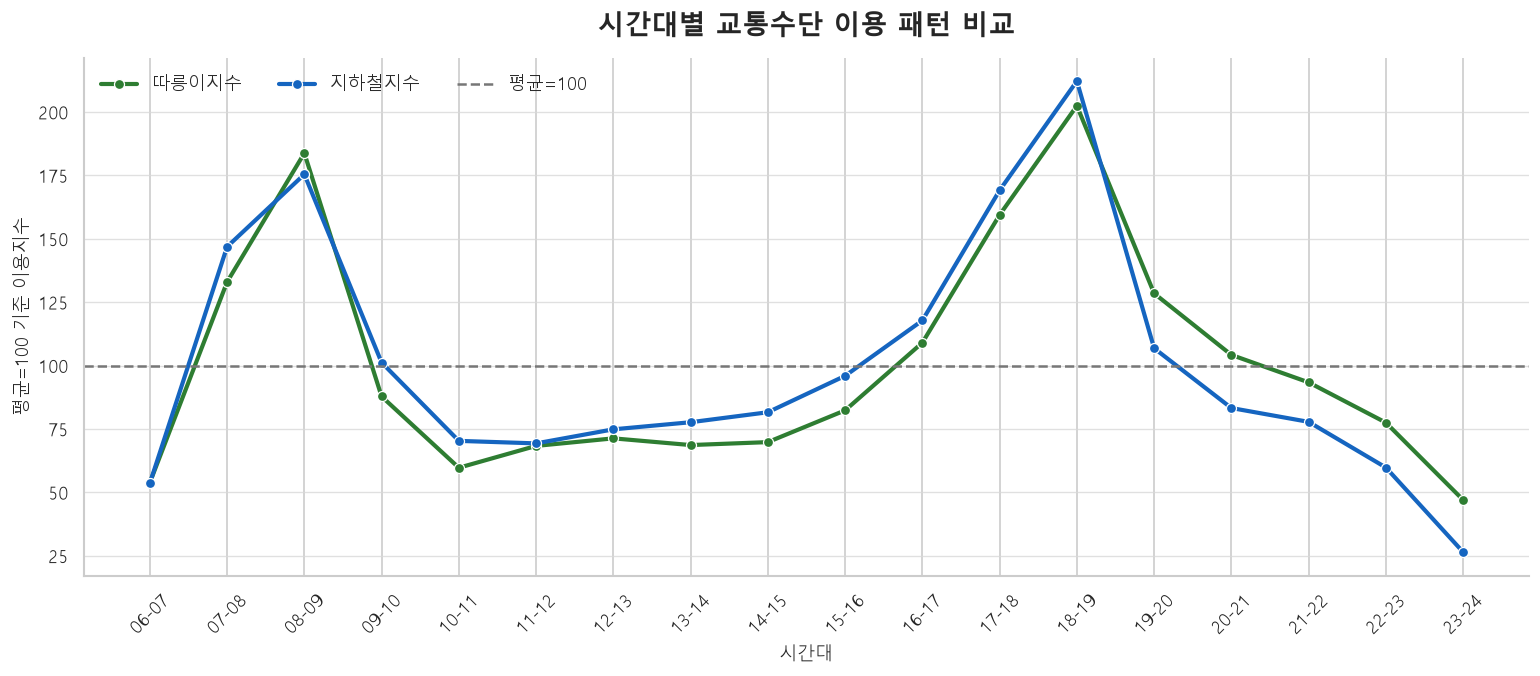

In [14]:
hourly['따릉이지수'] = hourly['평균따릉이'] / hourly['평균따릉이'].mean() * 100
hourly['지하철지수'] = hourly['평균지하철'] / hourly['평균지하철'].mean() * 100
hourly_index = hourly.melt(id_vars='시간대', value_vars=['따릉이지수','지하철지수'], var_name='교통수단', value_name='지수')

fig, ax = plt.subplots(figsize=(13,5.8))
sns.lineplot(data=hourly_index, x='시간대', y='지수', hue='교통수단', palette={'따릉이지수':BICYCLE_COLOR,'지하철지수':SUBWAY_COLOR}, marker='o', linewidth=2.5, ax=ax)
ax.axhline(100, linestyle='--', linewidth=1.5, color='#777777', label='평균=100')
style_ax(ax, '시간대별 교통수단 이용 패턴 비교', '시간대', '평균=100 기준 이용지수')
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False, ncol=3)
save_fig(fig, '09_시간대별_이용지수_비교')
plt.show()

## 6. 요일별 패턴

In [15]:
weekday_order = ['월','화','수','목','금']
weekday = (analysis_df.groupby('요일명').agg(평균따릉이=('따릉이대여건수','mean'), 평균지하철=('지하철승차인원','mean')).reindex(weekday_order).reset_index())

저장: eda_figures\10_요일별_평균따릉이.png


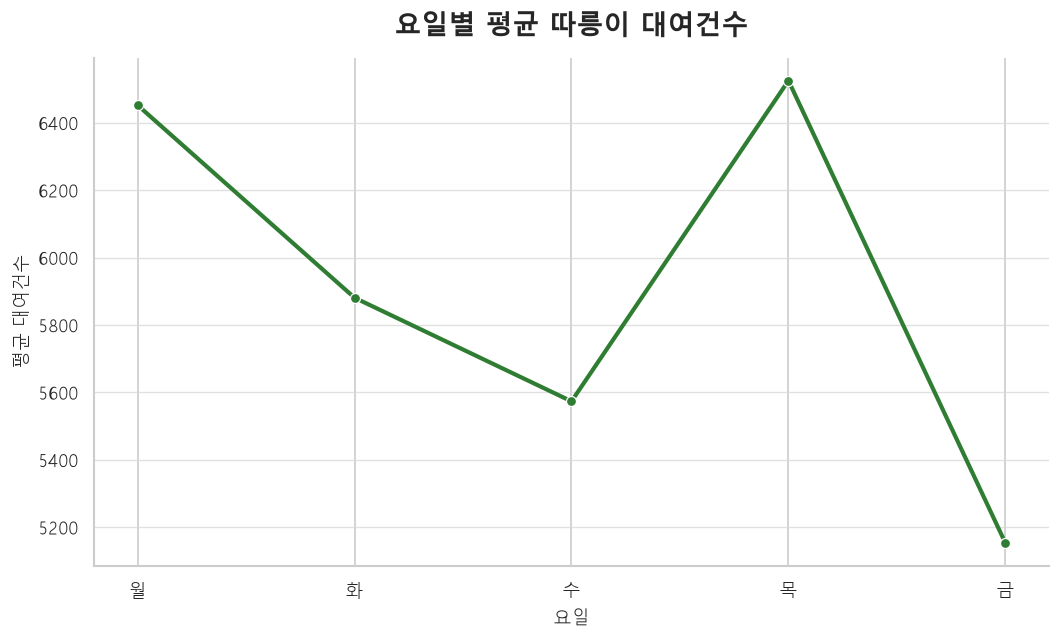

In [16]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.lineplot(data=weekday, x='요일명', y='평균따릉이', color=BICYCLE_COLOR, marker='o', linewidth=2.5, ax=ax)
style_ax(ax, '요일별 평균 따릉이 대여건수', '요일', '평균 대여건수')
save_fig(fig, '10_요일별_평균따릉이')
plt.show()

저장: eda_figures\11_요일별_평균지하철.png


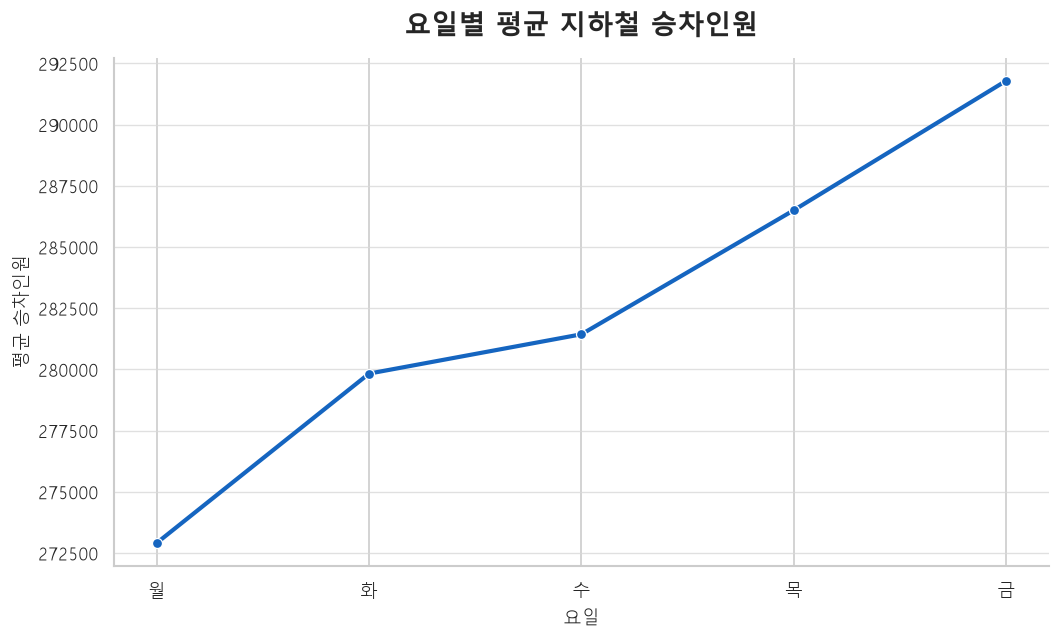

In [17]:
fig, ax = plt.subplots(figsize=(9,5.5))
sns.lineplot(data=weekday, x='요일명', y='평균지하철', color=SUBWAY_COLOR, marker='o', linewidth=2.5, ax=ax)
style_ax(ax, '요일별 평균 지하철 승차인원', '요일', '평균 승차인원')
save_fig(fig, '11_요일별_평균지하철')
plt.show()

## 7. 전체 상관관계

In [18]:
target_cols = ['기온(°C)','따릉이대여건수','지하철승차인원']
pearson_corr = analysis_df[target_cols].corr(method='pearson')
spearman_corr = spearman_corr(analysis_df, target_cols)
print('Pearson')
display(pearson_corr)
print('Spearman')
display(spearman_corr)

Pearson


,기온(°C),따릉이대여건수,지하철승차인원
기온(°C),1.000000,0.423440,0.012718
따릉이대여건수,0.423440,1.000000,0.652512
지하철승차인원,0.012718,0.652512,1.000000


Spearman


,기온(°C),따릉이대여건수,지하철승차인원
기온(°C),1.000000,0.462517,0.015601
따릉이대여건수,0.462517,1.000000,0.572017
지하철승차인원,0.015601,0.572017,1.000000


저장: eda_figures\12_전체_Spearman_상관관계.png


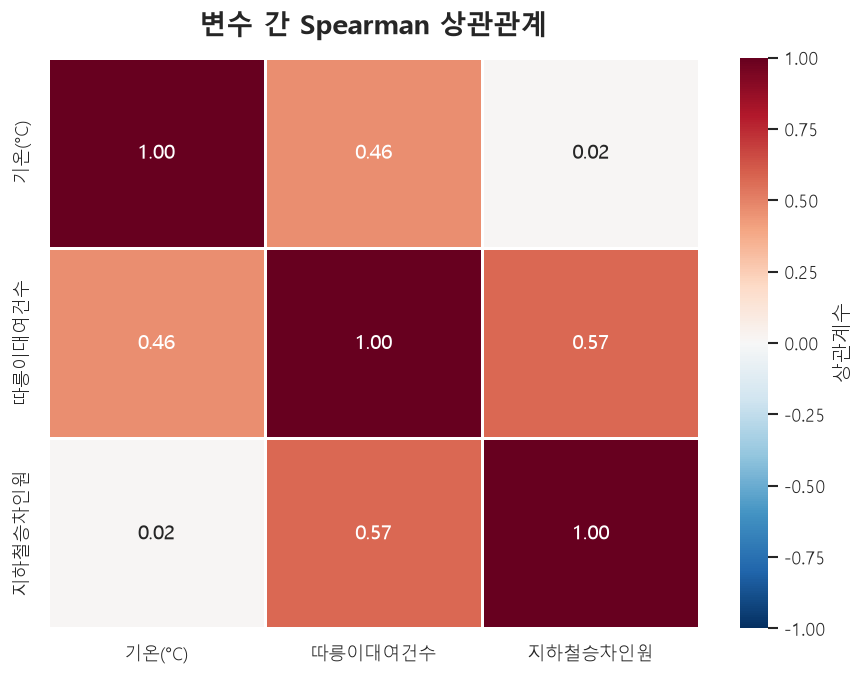

In [19]:
fig, ax = plt.subplots(figsize=(7.5,5.8))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=.7, cbar_kws={'label':'상관계수'}, ax=ax)
style_ax(ax, '변수 간 Spearman 상관관계', None, None)
save_fig(fig, '12_전체_Spearman_상관관계')
plt.show()

## 8. 기온과 이용량의 관계

저장: eda_figures\13_기온_vs_따릉이.png


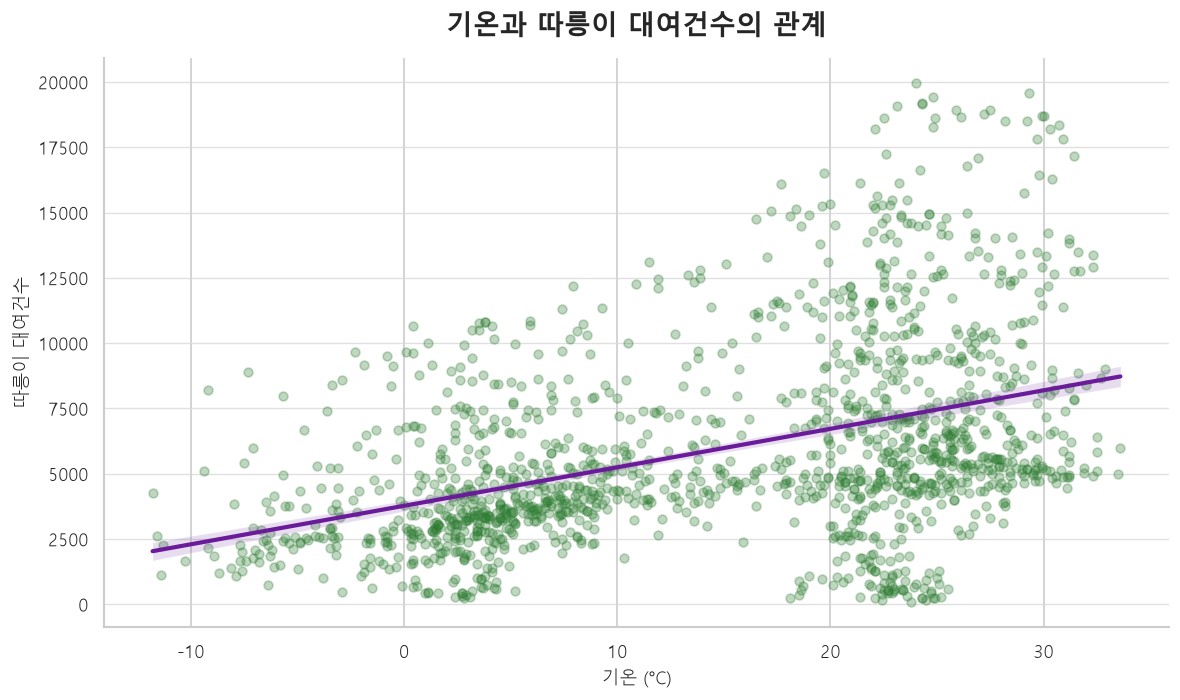

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=analysis_df, x='기온(°C)', y='따릉이대여건수', scatter_kws={'alpha':0.30,'s':28,'color':BICYCLE_COLOR}, line_kws={'color':ACCENT_COLOR,'linewidth':2.5}, ax=ax)
style_ax(ax, '기온과 따릉이 대여건수의 관계', '기온 (°C)', '따릉이 대여건수')
save_fig(fig, '13_기온_vs_따릉이')
plt.show()

저장: eda_figures\14_기온_vs_지하철.png


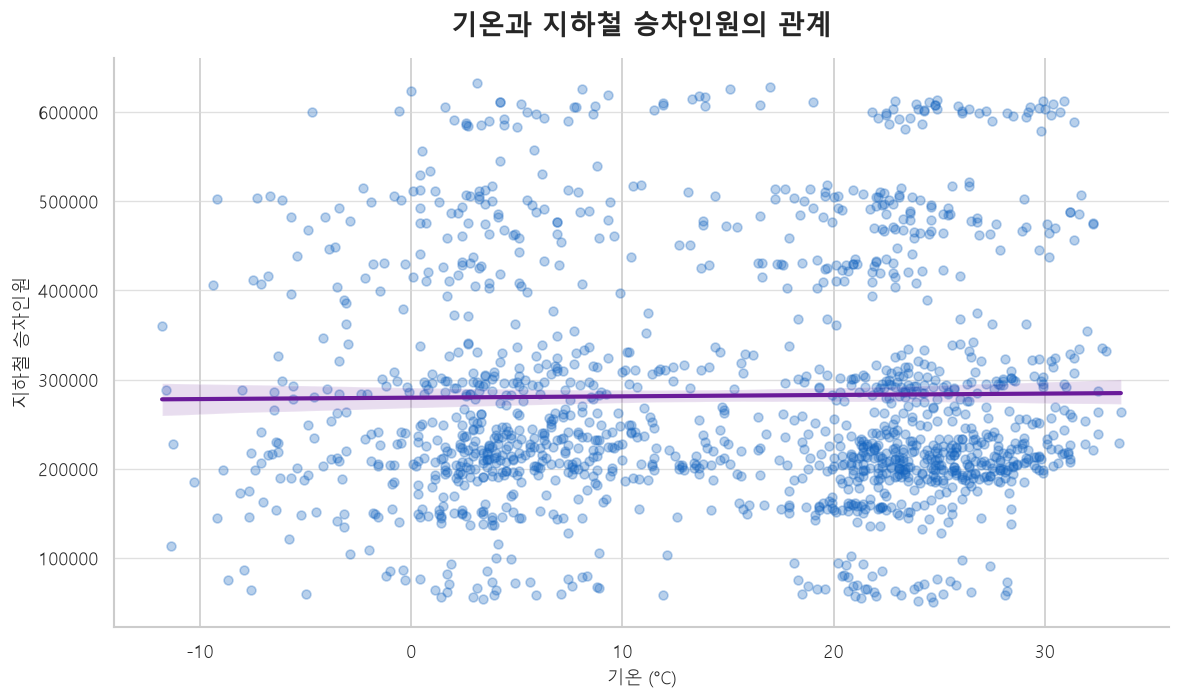

In [21]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=analysis_df, x='기온(°C)', y='지하철승차인원', scatter_kws={'alpha':0.30,'s':28,'color':SUBWAY_COLOR}, line_kws={'color':ACCENT_COLOR,'linewidth':2.5}, ax=ax)
style_ax(ax, '기온과 지하철 승차인원의 관계', '기온 (°C)', '지하철 승차인원')
save_fig(fig, '14_기온_vs_지하철')
plt.show()

저장: eda_figures\15_월별_기온_vs_따릉이.png


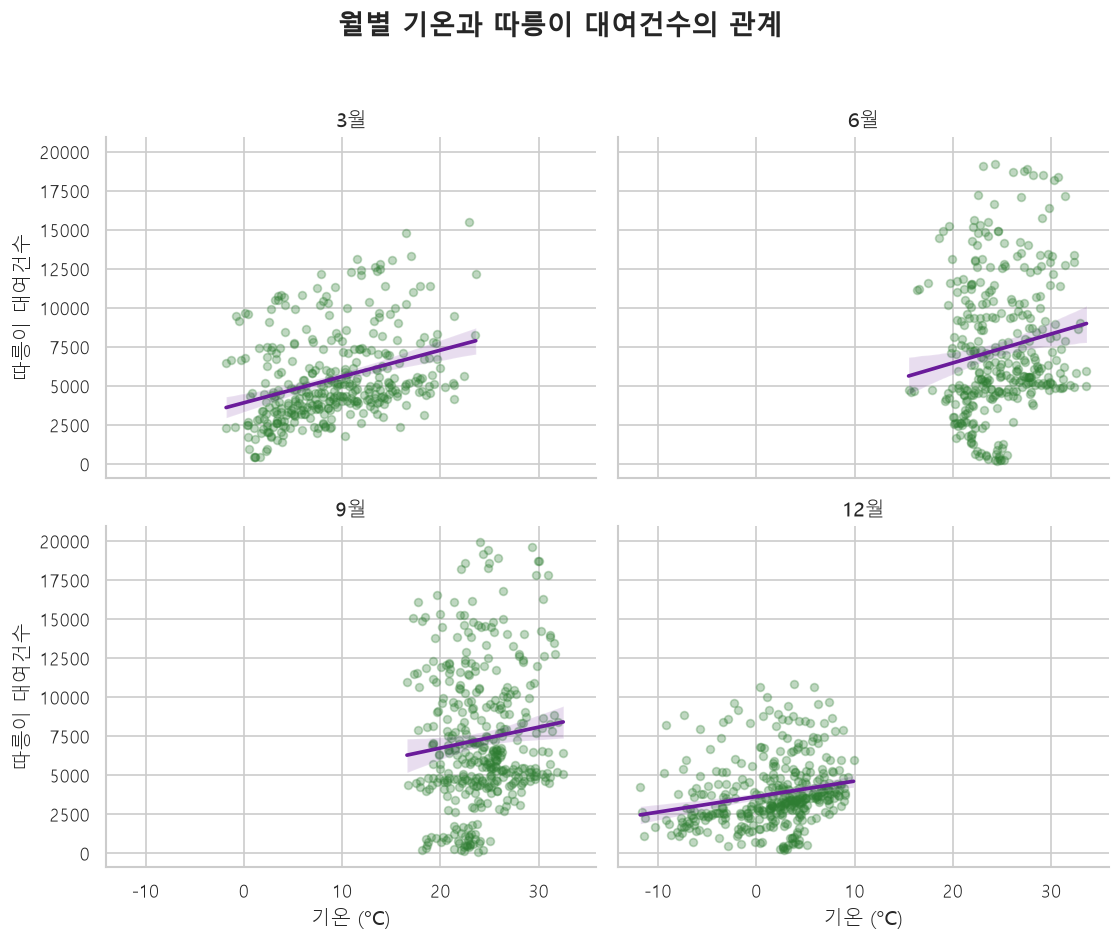

In [22]:
g = sns.lmplot(data=analysis_df, x='기온(°C)', y='따릉이대여건수', col='월명', col_order=['3월','6월','9월','12월'], col_wrap=2, height=3.8, aspect=1.25, scatter_kws={'alpha':0.30,'s':22,'color':BICYCLE_COLOR}, line_kws={'color':ACCENT_COLOR,'linewidth':2.2})
g.set_axis_labels('기온 (°C)', '따릉이 대여건수')
g.set_titles('{col_name}')
g.fig.suptitle('월별 기온과 따릉이 대여건수의 관계', fontsize=16, fontweight='bold', y=1.03)
g.fig.tight_layout()
g.fig.savefig(FIG_DIR/'15_월별_기온_vs_따릉이.png', bbox_inches='tight', facecolor='white', dpi=180)
print(f'저장: {FIG_DIR/"15_월별_기온_vs_따릉이.png"}')
plt.show()

## 9. 시간대별 기온 민감도

In [23]:
# hour_corr = []
# for hour, group in analysis_df.groupby('시간대', sort=False):
#     hour_corr.append({
#         '시간대': hour,
#         '따릉이_Pearson': group['기온(°C)'].corr(group['따릉이대여건수'], method='pearson'),
#         '따릉이_Spearman': spearman_corr(group[['기온(°C)','따릉이대여건수']]).iloc[0,1],
#         '지하철_Pearson': group['기온(°C)'].corr(group['지하철승차인원'], method='pearson'),
#         '지하철_Spearman': spearman_corr(group[['기온(°C)','지하철승차인원']]).iloc[0,1],
#         '관측수': len(group)
#     })
# hour_corr = pd.DataFrame(hour_corr)
# hour_corr_long = hour_corr.melt(id_vars=['시간대','관측수'], value_vars=['따릉이_Spearman','지하철_Spearman'], var_name='교통수단', value_name='상관계수')

## 9. 시간대별 기온 민감도

hour_corr = []

for hour, group in analysis_df.groupby('시간대', sort=False):

    # 기온-따릉이
    bicycle_pearson = group['기온(°C)'].corr(
        group['따릉이대여건수'],
        method='pearson'
    )

    bicycle_spearman = (
        group[['기온(°C)', '따릉이대여건수']]
        .rank(method='average')
        .corr(method='pearson')
        .iloc[0, 1]
    )

    # 기온-지하철
    subway_pearson = group['기온(°C)'].corr(
        group['지하철승차인원'],
        method='pearson'
    )

    subway_spearman = (
        group[['기온(°C)', '지하철승차인원']]
        .rank(method='average')
        .corr(method='pearson')
        .iloc[0, 1]
    )

    hour_corr.append({
        '시간대': hour,
        '따릉이_Pearson': bicycle_pearson,
        '따릉이_Spearman': bicycle_spearman,
        '지하철_Pearson': subway_pearson,
        '지하철_Spearman': subway_spearman,
        '관측수': len(group)
    })

hour_corr = pd.DataFrame(hour_corr)

hour_corr_long = hour_corr.melt(
    id_vars=['시간대', '관측수'],
    value_vars=['따릉이_Spearman', '지하철_Spearman'],
    var_name='교통수단',
    value_name='상관계수'
)

hour_corr

,시간대,따릉이_Pearson,따릉이_Spearman,지하철_Pearson,지하철_Spearman,관측수
0,06-07,0.650159,0.606754,0.629567,0.594331,83
1,07-08,0.629655,0.563861,0.406385,0.255571,83
2,08-09,0.529246,0.538705,0.209253,-0.049627,83
3,09-10,0.576198,0.590084,0.120794,-0.141302,83
4,10-11,0.602590,0.653206,-0.232470,-0.233819,83
5,11-12,0.634859,0.687955,-0.362898,-0.316978,83
6,12-13,0.640495,0.693469,-0.309155,-0.270146,83
7,13-14,0.547012,0.616343,-0.341086,-0.299822,83
8,14-15,0.517308,0.623771,-0.393030,-0.333001,83
9,15-16,0.580662,0.680676,-0.355340,-0.317025,83


저장: eda_figures\16_시간대별_기온_민감도.png


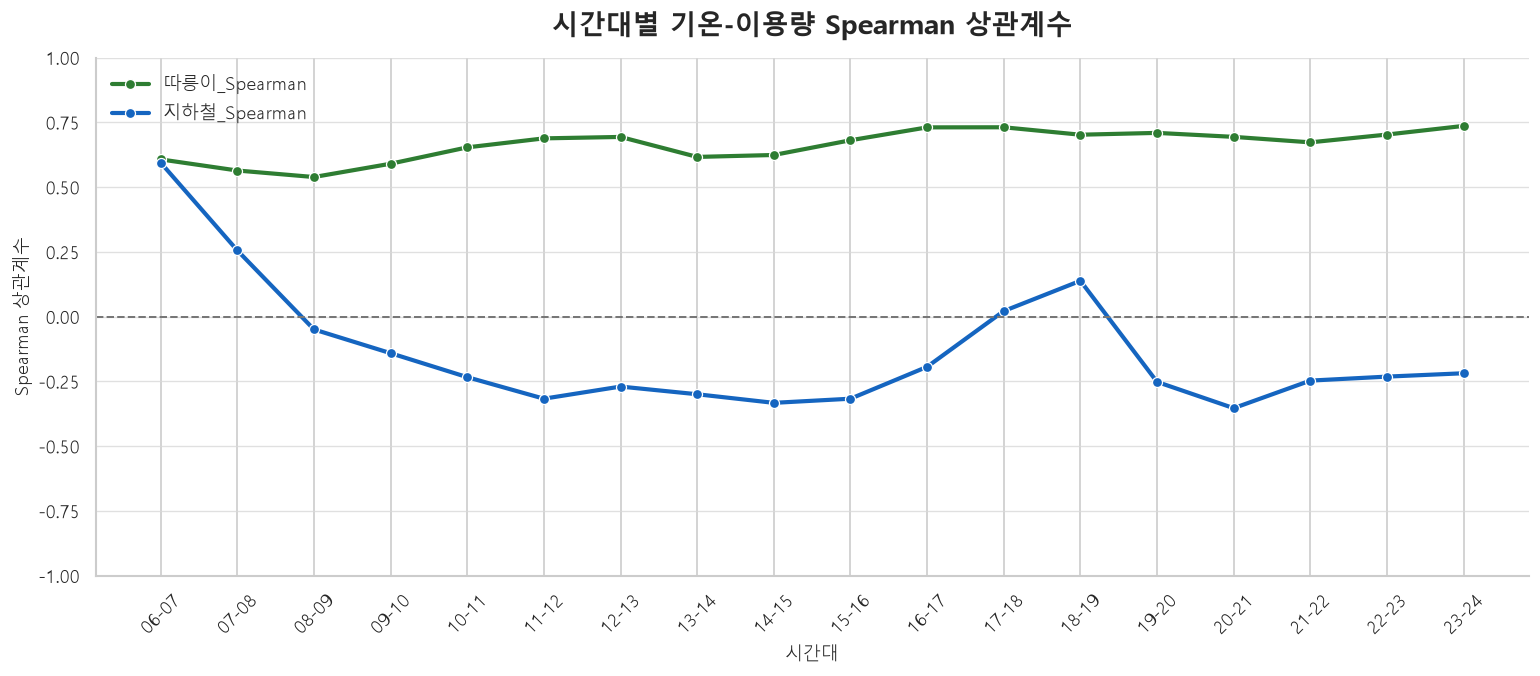

In [24]:
fig, ax = plt.subplots(figsize=(13,5.8))
sns.lineplot(data=hour_corr_long, x='시간대', y='상관계수', hue='교통수단', palette={'따릉이_Spearman':BICYCLE_COLOR,'지하철_Spearman':SUBWAY_COLOR}, marker='o', linewidth=2.5, ax=ax)
ax.axhline(0, linestyle='--', linewidth=1.2, color='#777777')
ax.set_ylim(-1,1)
style_ax(ax, '시간대별 기온-이용량 Spearman 상관계수', '시간대', 'Spearman 상관계수')
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
save_fig(fig, '16_시간대별_기온_민감도')
plt.show()

## 10. 기온 구간별 비교

In [25]:
bins = [-np.inf,0,5,10,15,20,25,30,np.inf]
labels = ['0℃ 미만','0~5℃','5~10℃','10~15℃','15~20℃','20~25℃','25~30℃','30℃ 이상']
analysis_df['기온구간_탐색'] = pd.cut(analysis_df['기온(°C)'], bins=bins, labels=labels, right=False)
temp_summary = (analysis_df.groupby('기온구간_탐색', observed=False).agg(평균기온=('기온(°C)','mean'), 평균따릉이=('따릉이대여건수','mean'), 평균지하철=('지하철승차인원','mean'), 관측수=('기온(°C)','size')).reset_index())
temp_summary

,기온구간_탐색,평균기온,평균따릉이,평균지하철,관측수
0,0℃ 미만,-4.214961,3382.149606,273449.984252,127
1,0~5℃,2.746377,3872.909420,280094.061594,276
2,5~10℃,7.204950,4891.599010,286759.183168,202
3,10~15℃,12.403125,6129.177083,296752.770833,96
4,15~20℃,18.054630,7332.101852,293804.129630,108
5,20~25℃,22.609424,6770.853403,276603.607330,382
6,25~30℃,27.191463,7725.211382,268614.487805,246
7,30℃ 이상,31.201754,8961.982456,338698.736842,57


저장: eda_figures\17_기온구간별_따릉이.png


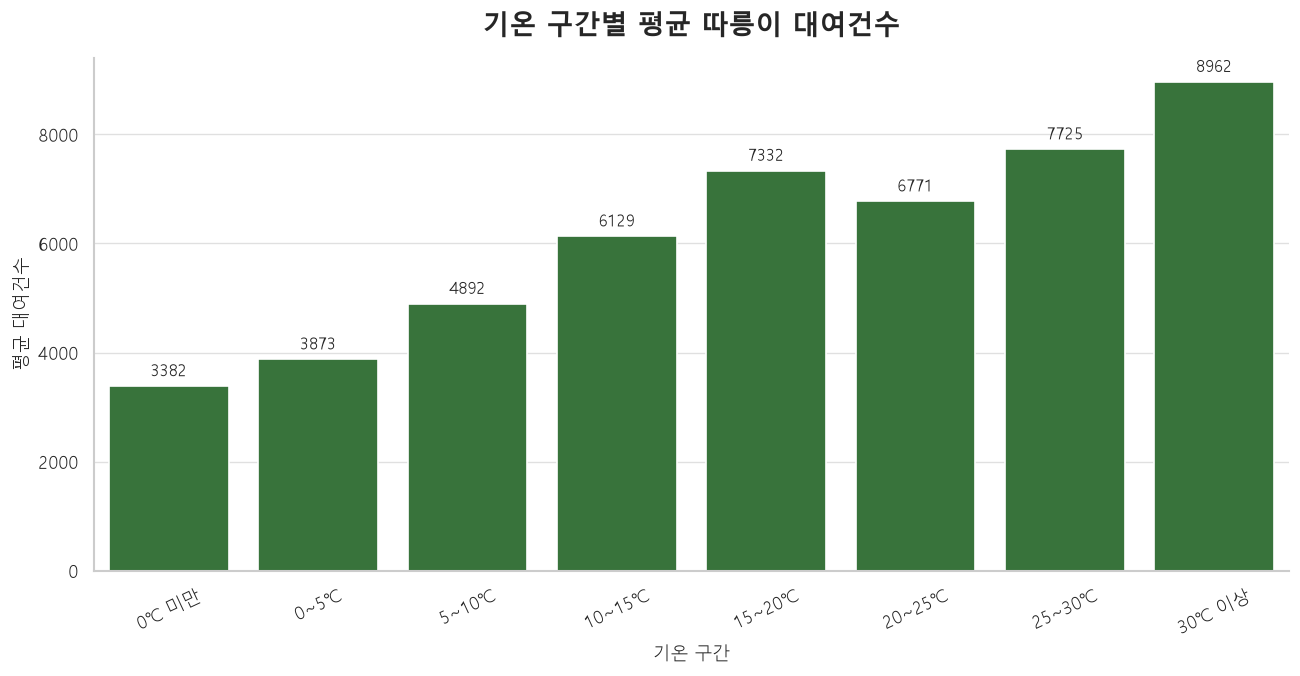

In [26]:
fig, ax = plt.subplots(figsize=(11,5.8))
sns.barplot(data=temp_summary, x='기온구간_탐색', y='평균따릉이', color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '기온 구간별 평균 따릉이 대여건수', '기온 구간', '평균 대여건수')
add_bar_labels(ax, fmt='{:.0f}')
ax.tick_params(axis='x', rotation=25)
save_fig(fig, '17_기온구간별_따릉이')
plt.show()

저장: eda_figures\18_기온구간별_지하철.png


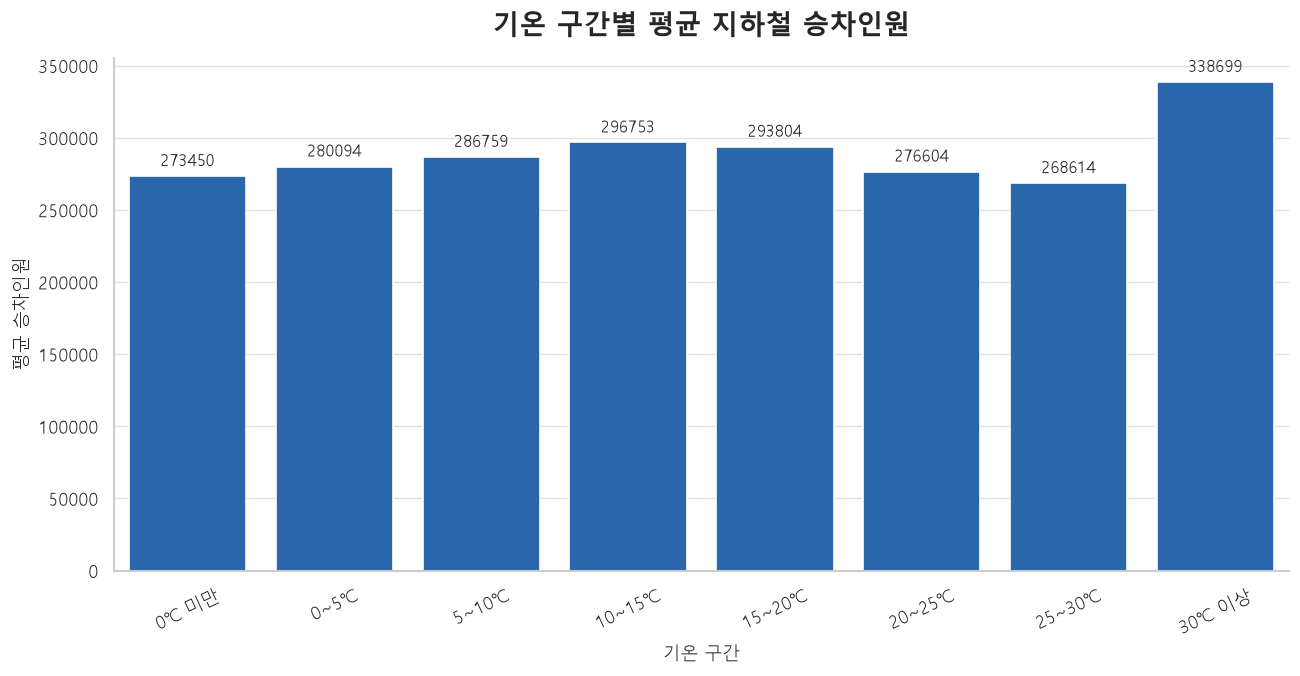

In [27]:
fig, ax = plt.subplots(figsize=(11,5.8))
sns.barplot(data=temp_summary, x='기온구간_탐색', y='평균지하철', color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '기온 구간별 평균 지하철 승차인원', '기온 구간', '평균 승차인원')
add_bar_labels(ax, fmt='{:.0f}')
ax.tick_params(axis='x', rotation=25)
save_fig(fig, '18_기온구간별_지하철')
plt.show()

저장: eda_figures\19_기온구간별_이용지수.png


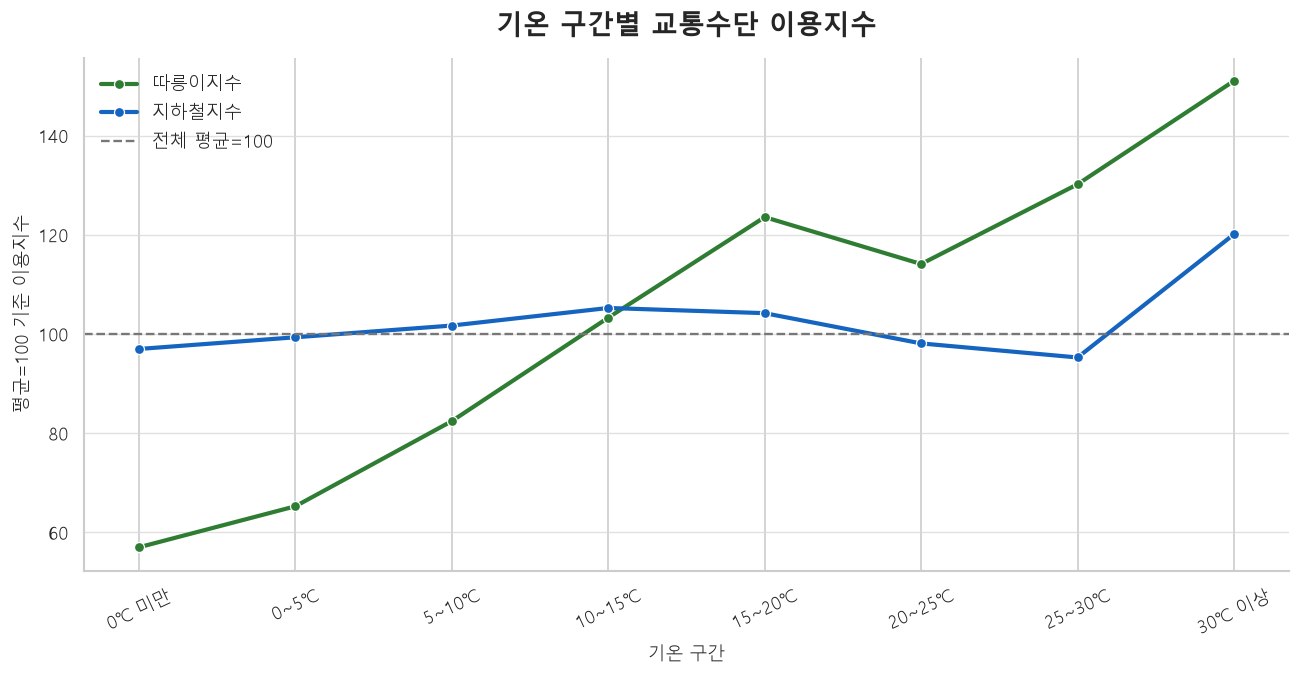

In [28]:
overall_bicycle_mean = analysis_df['따릉이대여건수'].mean()
overall_subway_mean = analysis_df['지하철승차인원'].mean()
temp_summary['따릉이지수'] = temp_summary['평균따릉이'] / overall_bicycle_mean * 100
temp_summary['지하철지수'] = temp_summary['평균지하철'] / overall_subway_mean * 100
temp_index = temp_summary.melt(id_vars=['기온구간_탐색','관측수'], value_vars=['따릉이지수','지하철지수'], var_name='교통수단', value_name='이용지수')

fig, ax = plt.subplots(figsize=(11,5.8))
sns.lineplot(data=temp_index, x='기온구간_탐색', y='이용지수', hue='교통수단', palette={'따릉이지수':BICYCLE_COLOR,'지하철지수':SUBWAY_COLOR}, marker='o', linewidth=2.5, ax=ax)
ax.axhline(100, linestyle='--', linewidth=1.4, color='#777777', label='전체 평균=100')
style_ax(ax, '기온 구간별 교통수단 이용지수', '기온 구간', '평균=100 기준 이용지수')
ax.tick_params(axis='x', rotation=25)
ax.legend(frameon=False)
save_fig(fig, '19_기온구간별_이용지수')
plt.show()

## 11. 일 단위 집계로 재확인

In [29]:
daily = analysis_df.groupby('날짜').agg(평균기온=('기온(°C)','mean'), 총따릉이=('따릉이대여건수','sum'), 총지하철=('지하철승차인원','sum')).reset_index()
daily.head()

,날짜,평균기온,총따릉이,총지하철
0,2025-03-04,2.477778,48302,4735238.0
1,2025-03-05,5.494444,85109,4991261.0
2,2025-03-06,5.822222,89896,5075082.0
3,2025-03-07,6.300000,92997,5235135.0
4,2025-03-10,9.227778,99341,4974804.0


저장: eda_figures\20_일평균기온_vs_일일따릉이.png


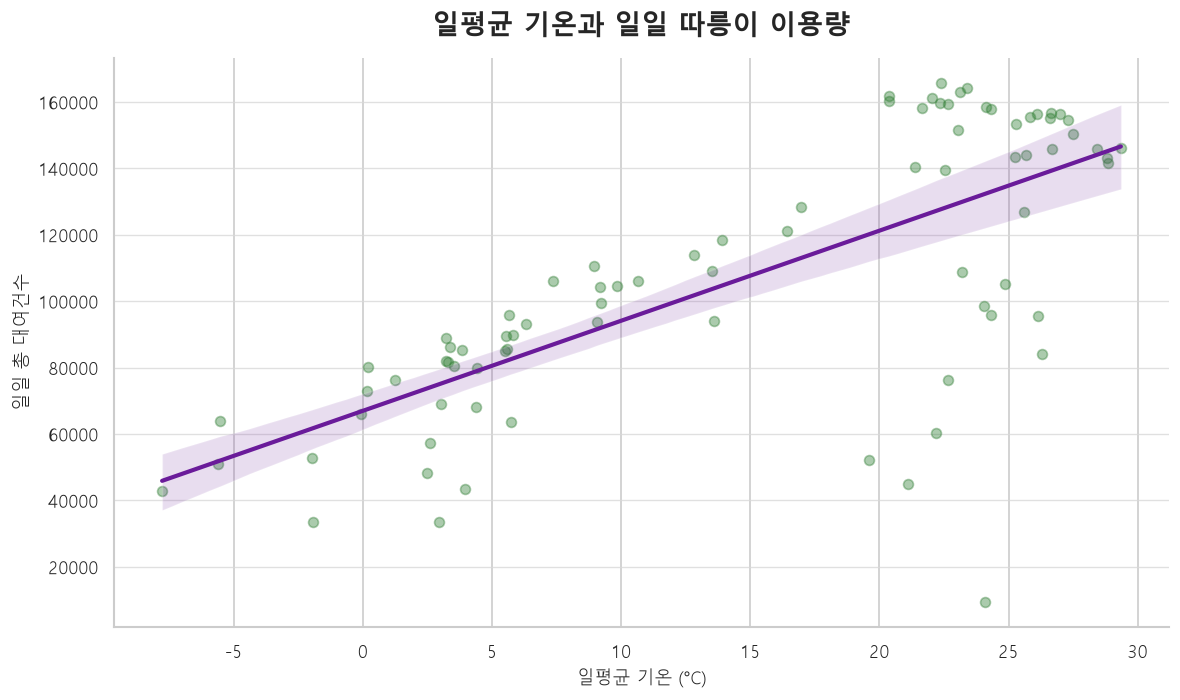

In [30]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=daily, x='평균기온', y='총따릉이', scatter_kws={'alpha':0.40,'s':35,'color':BICYCLE_COLOR}, line_kws={'color':ACCENT_COLOR,'linewidth':2.5}, ax=ax)
style_ax(ax, '일평균 기온과 일일 따릉이 이용량', '일평균 기온 (°C)', '일일 총 대여건수')
save_fig(fig, '20_일평균기온_vs_일일따릉이')
plt.show()

저장: eda_figures\21_일평균기온_vs_일일지하철.png


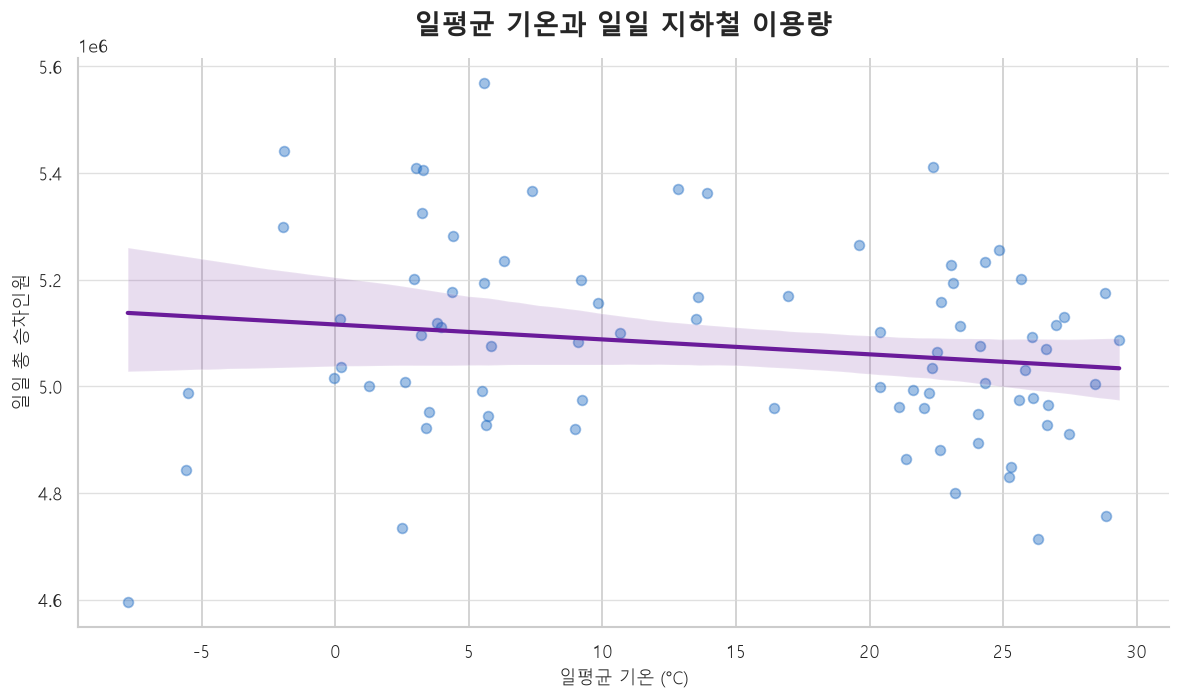

In [31]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=daily, x='평균기온', y='총지하철', scatter_kws={'alpha':0.40,'s':35,'color':SUBWAY_COLOR}, line_kws={'color':ACCENT_COLOR,'linewidth':2.5}, ax=ax)
style_ax(ax, '일평균 기온과 일일 지하철 이용량', '일평균 기온 (°C)', '일일 총 승차인원')
save_fig(fig, '21_일평균기온_vs_일일지하철')
plt.show()

## 12. 월 × 시간대 패턴

저장: eda_figures\22_월별_시간대별_따릉이_히트맵.png


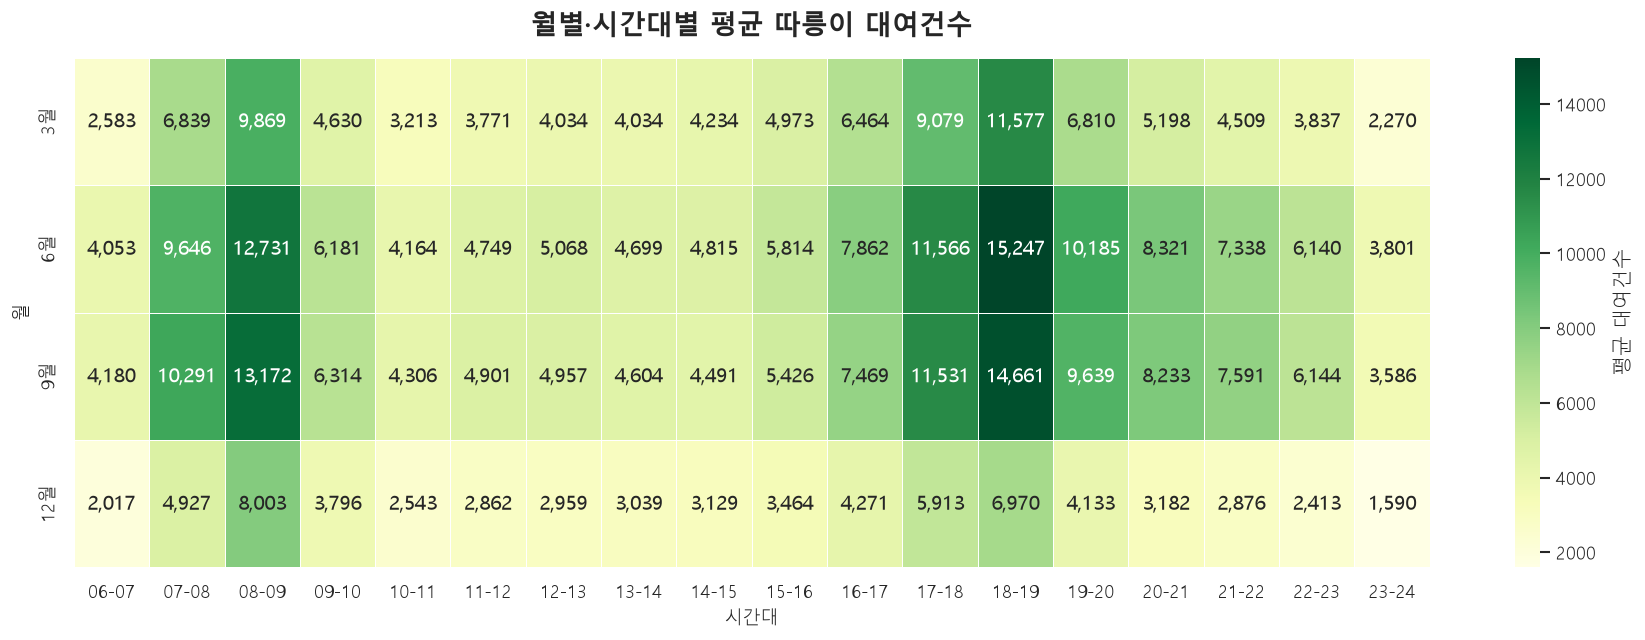

In [32]:
heat_bicycle = analysis_df.pivot_table(index='월명', columns='시간대', values='따릉이대여건수', aggfunc='mean').reindex(['3월','6월','9월','12월']).reindex(columns=hour_order)
fig, ax = plt.subplots(figsize=(15,5.5))
sns.heatmap(heat_bicycle, annot=True, fmt=',.0f', cmap='YlGn', linewidths=.5, cbar_kws={'label':'평균 대여건수'}, ax=ax)
style_ax(ax, '월별·시간대별 평균 따릉이 대여건수', '시간대', '월')
save_fig(fig, '22_월별_시간대별_따릉이_히트맵')
plt.show()

저장: eda_figures\23_월별_시간대별_지하철_히트맵.png


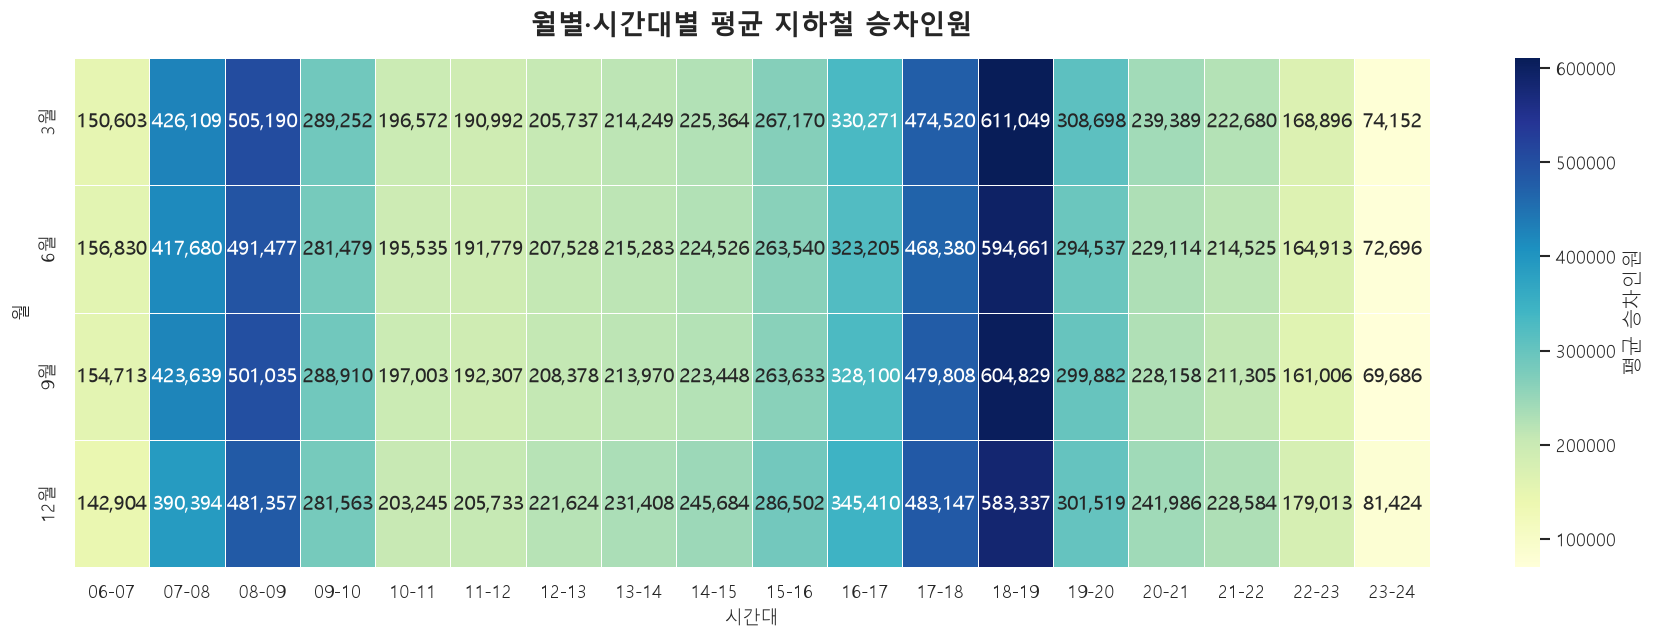

In [33]:
heat_subway = analysis_df.pivot_table(index='월명', columns='시간대', values='지하철승차인원', aggfunc='mean').reindex(['3월','6월','9월','12월']).reindex(columns=hour_order)
fig, ax = plt.subplots(figsize=(15,5.5))
sns.heatmap(heat_subway, annot=True, fmt=',.0f', cmap='YlGnBu', linewidths=.5, cbar_kws={'label':'평균 승차인원'}, ax=ax)
style_ax(ax, '월별·시간대별 평균 지하철 승차인원', '시간대', '월')
save_fig(fig, '23_월별_시간대별_지하철_히트맵')
plt.show()

## 13. 발표용 핵심 수치 확인

In [35]:
## 13. 발표용 핵심 수치 확인

print("===== 발표용 핵심 수치 =====")

print(f"평균 기온: {analysis_df['기온(°C)'].mean():.1f}°C")
print(f"평균 따릉이 대여: {analysis_df['따릉이대여건수'].mean():,.0f}건/시간대")
print(f"평균 지하철 승차: {analysis_df['지하철승차인원'].mean():,.0f}명/시간대")

# Pearson
bicycle_pearson = analysis_df['기온(°C)'].corr(
    analysis_df['따릉이대여건수'],
    method='pearson'
)

subway_pearson = analysis_df['기온(°C)'].corr(
    analysis_df['지하철승차인원'],
    method='pearson'
)

# Spearman
bicycle_spearman = (
    analysis_df[['기온(°C)', '따릉이대여건수']]
    .rank(method='average')
    .corr(method='pearson')
    .iloc[0, 1]
)

subway_spearman = (
    analysis_df[['기온(°C)', '지하철승차인원']]
    .rank(method='average')
    .corr(method='pearson')
    .iloc[0, 1]
)

print(f"기온-따릉이 Pearson: {bicycle_pearson:.3f}")
print(f"기온-지하철 Pearson: {subway_pearson:.3f}")
print(f"기온-따릉이 Spearman: {bicycle_spearman:.3f}")
print(f"기온-지하철 Spearman: {subway_spearman:.3f}")

===== 발표용 핵심 수치 =====
평균 기온: 14.7°C
평균 따릉이 대여: 5,933건/시간대
평균 지하철 승차: 281,945명/시간대
기온-따릉이 Pearson: 0.423
기온-지하철 Pearson: 0.013
기온-따릉이 Spearman: 0.463
기온-지하철 Spearman: 0.016
